# EDA
This notebook includes initial basic EDA for the clean NPORS 2025 data.

In [106]:
library(tidyverse)
npors_2025 <- read_csv('../data/cleandata/NPORS_2025_clean.csv')

Rows: 5022 Columns: 56
── Column specification ────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (53): STRATUM, ECON1MOD, ECON1BMOD, COMTYPE2, UNITY, CRIMESAFE, GOVPROTCT, MOREGUNIMPACT, FIN_SI...
dbl  (3): RESPID, BASEWT, WEIGHT

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [107]:
library(sf)
library(ggplot2)

census_regions <- st_read("../data/rawdata/cb_2023_us_region_5m/cb_2023_us_region_5m.shp")
census_regions <- st_transform(census_regions, 4326)

Reading layer `cb_2023_us_region_5m' from data source 
  `C:\Users\kykin\OneDrive\Desktop\DSAN5200\project\data\rawdata\cb_2023_us_region_5m\cb_2023_us_region_5m.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 4 features and 8 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -179.1473 ymin: 18.91314 xmax: 179.7785 ymax: 71.35256
Geodetic CRS:  NAD83


In [108]:
#restricting the polygons for a simpler map
bbox <- st_bbox(c(
  xmin = -125,
  xmax = -60,
  ymin = -90,
  ymax = 90
), crs = st_crs(census_regions))

census_regions <- st_crop(census_regions, bbox)

Warning message:
attribute variables are assumed to be spatially constant throughout all geometries 


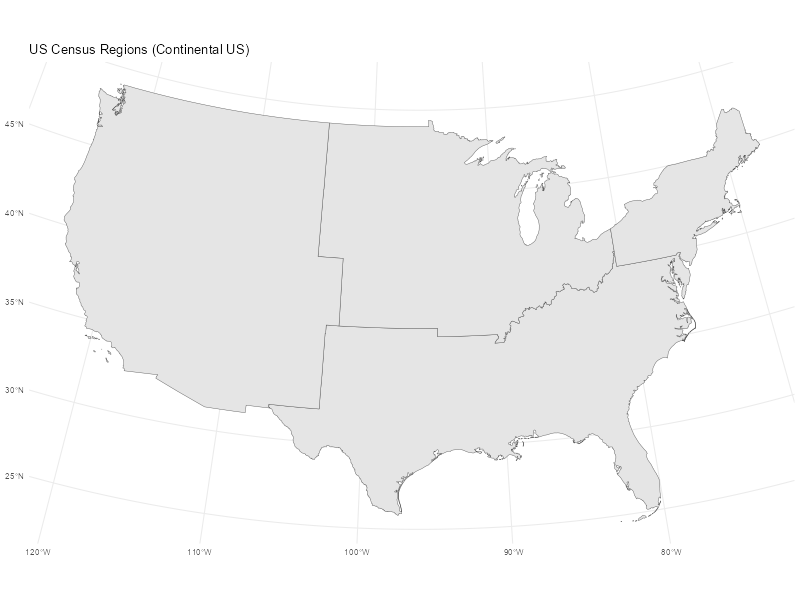

In [109]:
census_regions <- st_transform(census_regions, 5070) #US albers
ggplot(census_regions) +
  geom_sf() +
  theme_minimal() +
  ggtitle("US Census Regions (Continental US)")

I want to make a choropleth of which census regions voted which way in the 2024 election, then another identical map where I exclude the female votes

In [83]:
#getting the raw vote counts by census region
vote_counts <- npors_2025 |>
  filter(VOTEGEN_POST %in% c("Donald Trump, the Republican",
                             "Kamala Harris, the Democrat")) |>
  group_by(CREGION, VOTEGEN_POST) |>
  summarise(votes = n(), .groups = "drop")

In [84]:
vote_wide <- vote_counts |>
  pivot_wider(names_from = VOTEGEN_POST, values_from = votes, values_fill = 0)
region_margin <- vote_wide |>
  mutate(
    total = `Donald Trump, the Republican` + `Kamala Harris, the Democrat`,
    margin = (`Donald Trump, the Republican` -
              `Kamala Harris, the Democrat`) / total
  )
#positive values = trump popular, negative values = harris popular

In [85]:
#joining to the map
census_regions <- census_regions |>
  left_join(region_margin, by = c("NAME" = "CREGION"))

In [86]:
# now if it was only women voting
women_2025 <- npors_2025 |>
  filter(GENDER == "A woman")

In [87]:
#getting the raw vote counts by census region
vote_counts <- women_2025 |>
  filter(VOTEGEN_POST %in% c("Donald Trump, the Republican",
                             "Kamala Harris, the Democrat")) |>
  group_by(CREGION, VOTEGEN_POST) |>
  summarise(votes = n(), .groups = "drop")

vote_wide <- vote_counts |>
  pivot_wider(names_from = VOTEGEN_POST, values_from = votes, values_fill = 0)
region_margin <- vote_wide |>
  mutate(
    total = `Donald Trump, the Republican` + `Kamala Harris, the Democrat`,
    women_margin = (`Donald Trump, the Republican` -
              `Kamala Harris, the Democrat`) / total
  )
#positive values = trump popular, negative values = harris popular


In [88]:
region_margin <- region_margin|> select(-`Donald Trump, the Republican`,-`Kamala Harris, the Democrat`,-`total`)

In [89]:
census_regions <- census_regions |>
  left_join(region_margin, by = c("NAME" = "CREGION"))

In [90]:
#and men
men_2025 <- npors_2025 |>
  filter(GENDER == "A man")

In [91]:
#getting the raw vote counts by census region
vote_counts <- men_2025 |>
  filter(VOTEGEN_POST %in% c("Donald Trump, the Republican",
                             "Kamala Harris, the Democrat")) |>
  group_by(CREGION, VOTEGEN_POST) |>
  summarise(votes = n(), .groups = "drop")

vote_wide <- vote_counts |>
  pivot_wider(names_from = VOTEGEN_POST, values_from = votes, values_fill = 0)
region_margin <- vote_wide |>
  mutate(
    total = `Donald Trump, the Republican` + `Kamala Harris, the Democrat`,
    men_margin = (`Donald Trump, the Republican` -
              `Kamala Harris, the Democrat`) / total
  )
#positive values = trump popular, negative values = harris popular

In [92]:
region_margin|> select(-`Donald Trump, the Republican`,-`Kamala Harris, the Democrat`,-`total`)

# A tibble: 4 × 2
  CREGION   men_margin
  <chr>          <dbl>
1 Midwest       0.0127
2 Northeast    -0.0588
3 South         0.171 
4 West         -0.0260

In [93]:
census_regions <- census_regions |>
  left_join(region_margin, by = c("NAME" = "CREGION"))

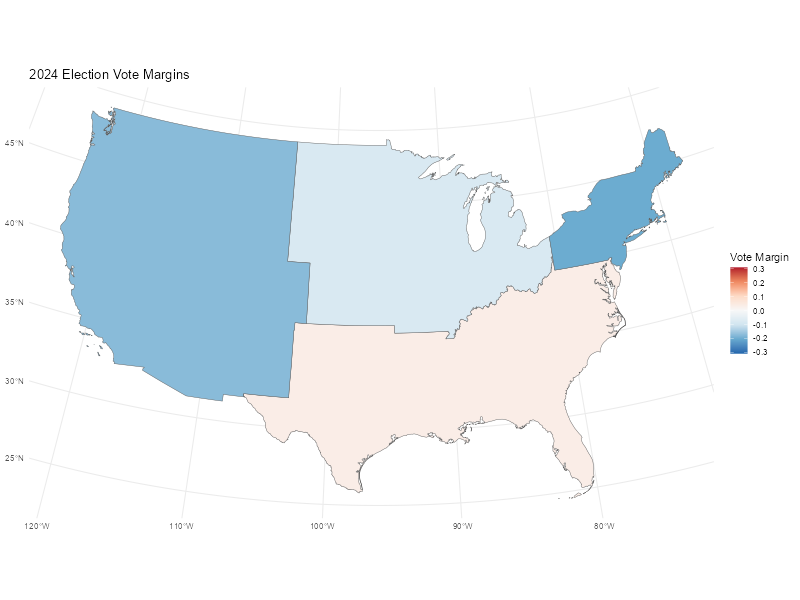

In [94]:
# making sure this splits at 0 and shows the full range
max_margin <- max(abs(census_regions$women_margin), na.rm = TRUE)

ggplot(census_regions) +
  geom_sf(aes(fill = margin)) +
  scale_fill_distiller(
    palette = "RdBu",
    direction = -1,
    limits = c(-max_margin, max_margin),
    name = "Vote Margin"
  ) +
  theme_minimal() +
  ggtitle("2024 Election Vote Margins")

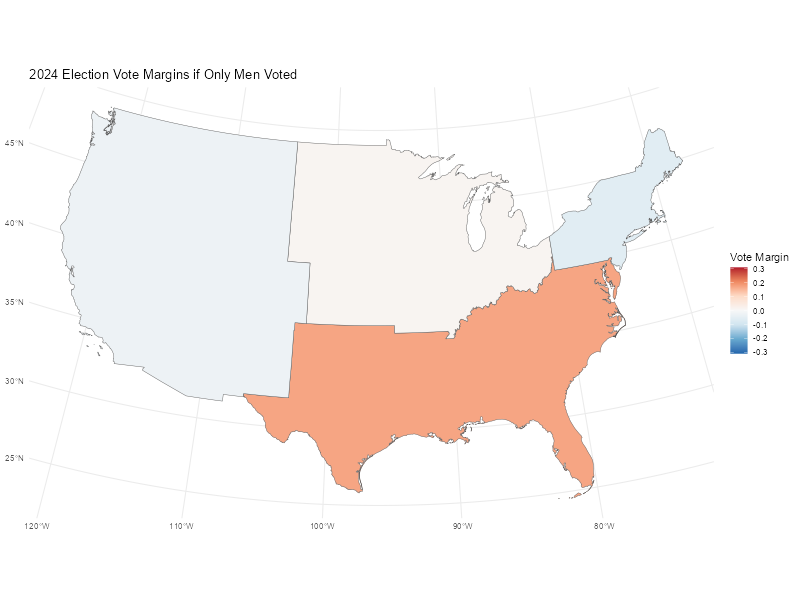

In [96]:
ggplot(census_regions) +
  geom_sf(aes(fill = men_margin)) +
  scale_fill_distiller(
    palette = "RdBu",
    direction = -1,
    limits = c(-max_margin, max_margin),
    name = "Vote Margin"
  ) +
  theme_minimal()+
  ggtitle("2024 Election Vote Margins if Only Men Voted")

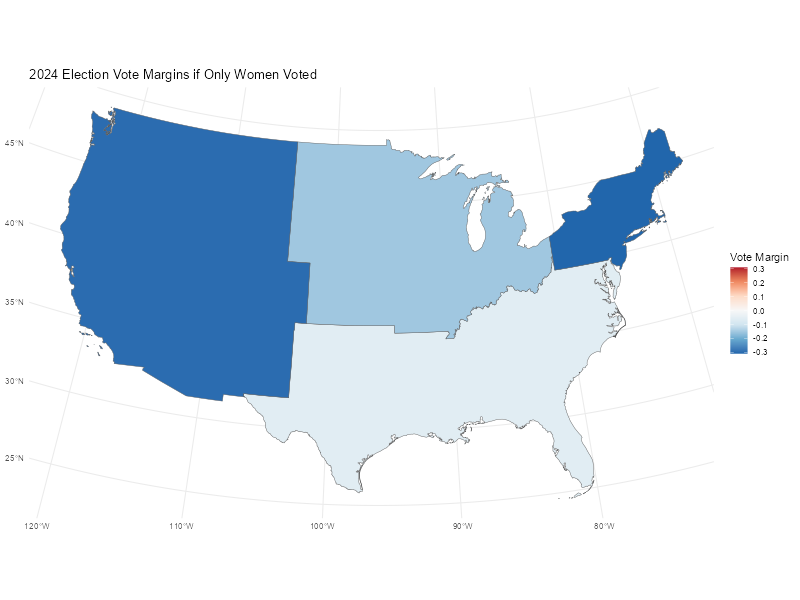

In [97]:
ggplot(census_regions) +
  geom_sf(aes(fill = women_margin)) +
  scale_fill_distiller(
    palette = "RdBu",
    direction = -1,
    limits = c(-max_margin, max_margin),
    name = "Vote Margin"
  ) +
  theme_minimal()+
  ggtitle("2024 Election Vote Margins if Only Women Voted")

The idea would be to do this same task but with state-level data, or with the data on battleground states that we have from CNN exit polling